## Import section

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.regressionplots import plot_partregress_grid
from sklearn.model_selection import TimeSeriesSplit


## EDA

In [41]:
# First, the dataframe is imported and then inspected.

In [42]:
df = pd.read_excel('AirQualityUCI.xlsx')
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [43]:
df.dtypes
# The data types contained in the dataset are examined.

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

In [44]:
df = df.replace(-200, np.nan)
df = df.dropna()
df.isnull().sum()
# The dataset contains missing values labeled as -200 by the research team; these values are removed from the dataset. Possible missing values within the dataset are also checked.

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

## Correlation and predictor relevance



In [45]:
# Correlation between the target CO(GT) and regression predictors (PT08.S1(CO), T, RH). AH is included to show why it was dropped (multicollinearity with T/RH).

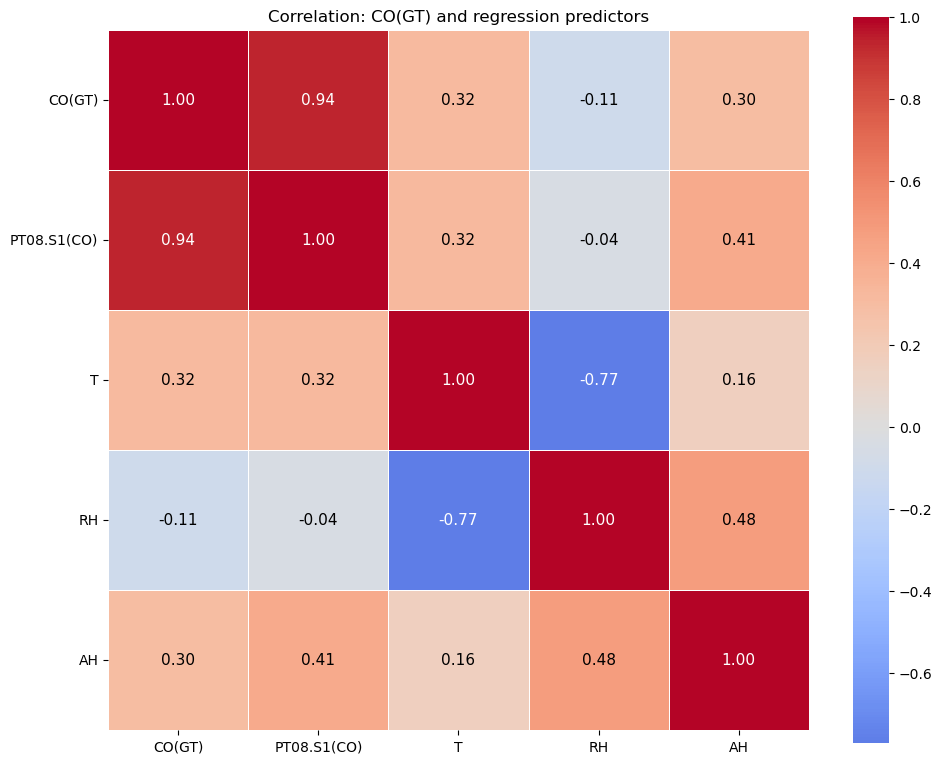

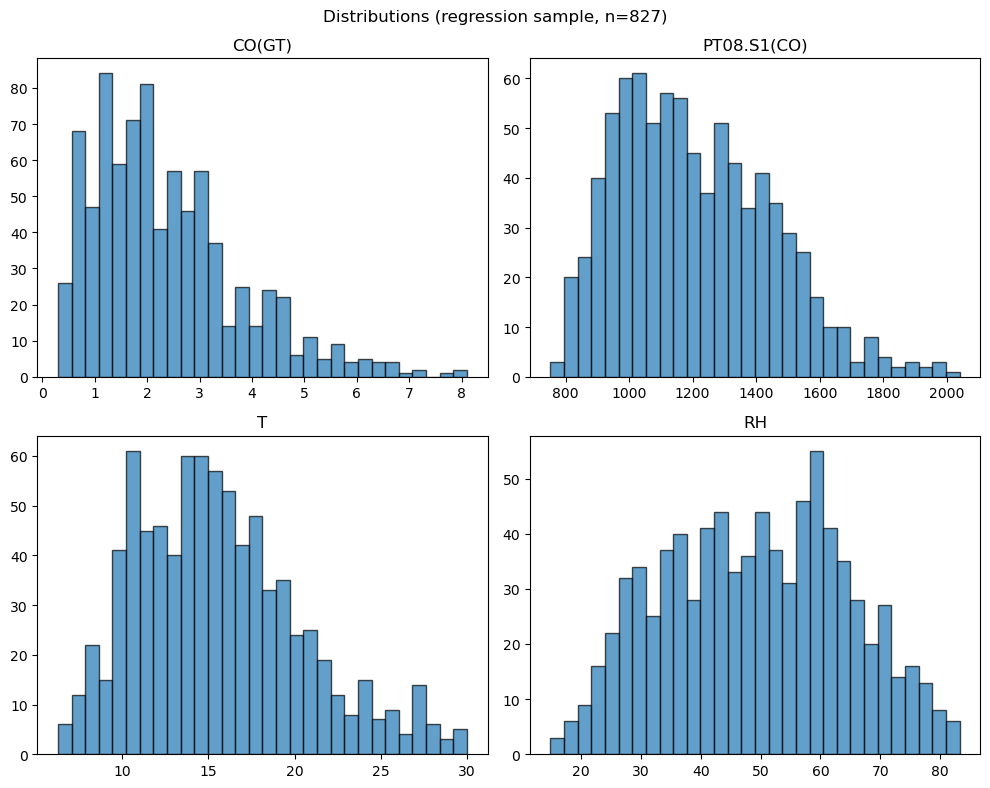

In [46]:
# Correlation heatmap for target and main predictors
cols_corr = ['CO(GT)', 'PT08.S1(CO)', 'T', 'RH', 'AH']
corr = df[cols_corr].corr()

plt.figure(figsize=(10, 8))

# Create heatmap without default annotations
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=True,
    annot=False
)

# Add correlation values manually for better visibility
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{value:.2f}",
            ha='center',
            va='center',
            color='white' if abs(value) > 0.5 else 'black',
            fontsize=11
        )

plt.title("Correlation: CO(GT) and regression predictors")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Univariate distributions of key variables
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(df['CO(GT)'], bins=30, edgecolor='k', alpha=0.7)
axes[0,0].set_title('CO(GT)')

axes[0,1].hist(df['PT08.S1(CO)'], bins=30, edgecolor='k', alpha=0.7)
axes[0,1].set_title('PT08.S1(CO)')

axes[1,0].hist(df['T'], bins=30, edgecolor='k', alpha=0.7)
axes[1,0].set_title('T')

axes[1,1].hist(df['RH'], bins=30, edgecolor='k', alpha=0.7)
axes[1,1].set_title('RH')

plt.suptitle('Distributions (regression sample, n=827)')
plt.tight_layout()
plt.show()

In [47]:
# The histograms show the distribution of the main variables used in the regression sample. This helps visualize the data and understand their general patterns before running the regression.

## Baseline Model: Sensor-Based Regression

Linear Regression: Predicting CO(GT) Using Sensor and Weather Variables

In [48]:
# Define variables for the baseline model (sensor + weather)
x_CO = df[['PT08.S1(CO)','T','RH','AH']]
y_CO = df['CO(GT)']

# Train model without adjustments to see initial behavior
model_CO = LinearRegression()
model_CO.fit(x_CO, y_CO)

# Print coefficients to see which variables are driving the model
print("Intercept:", model_CO.intercept_)
print("\nCoefficients:")

for var, coef in zip(x_CO.columns, model_CO.coef_):
    print(f"{var}: {coef:.4f}")   

Intercept: -3.557274671961339

Coefficients:
PT08.S1(CO): 0.0057
T: -0.0137
RH: -0.0070
AH: -0.4423


In [49]:
# Add constant for OLS
x_CO = sm.add_constant(x_CO)
# Fit model to check significance and R²
model_CO = sm.OLS(y_CO, x_CO).fit()
# Display full regression results
print(model_CO.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     1595.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:08:34   Log-Likelihood:                -559.28
No. Observations:                 827   AIC:                             1129.
Df Residuals:                     822   BIC:                             1152.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.5573      0.286    -12.431      

In [50]:
# Check multicollinearity between variables
x_CO_const = sm.add_constant(x_CO)

# VIF
vif_data = pd.DataFrame()
vif_data["variable"] = x_CO_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_CO_const.values, i)
                   for i in range(x_CO_const.shape[1])]

print(vif_data)

      variable         VIF
0        const  297.283815
1  PT08.S1(CO)    1.309665
2            T   20.390888
3           RH   25.716111
4           AH   11.023311


In [51]:
# The Variance Inflation Factor (VIF) test reveals high multicollinearity among the meteorological variables. 
# Absolute Humidity (AH) shows a VIF greater than 10 and is theoretically related to temperature (T) and relative humidity (RH). 
# To reduce multicollinearity and improve model stability, AH is removed from the regression model.

## Refined Model: Regression Without Absolute Humidity (AH)

In [52]:
# Define variables without AH to reduce multicollinearity
x_CO2 = df[['PT08.S1(CO)', 'T', 'RH']]
y_CO2 = df['CO(GT)']

# Train updated model after removing redundant variable
model_CO2 = LinearRegression()
model_CO2.fit(x_CO2, y_CO2)

# Print results to compare changes vs previous model
print("Intercept:", round(model_CO2.intercept_, 4))
print("\nCoefficients:")

for var, coef in zip(x_CO2.columns, model_CO2.coef_):
    print(f"{var}: {coef:.4f}")

Intercept: -3.2174

Coefficients:
PT08.S1(CO): 0.0056
T: -0.0342
RH: -0.0145


In [53]:
# Add constant for OLS regression
x_CO2 = sm.add_constant(x_CO2)
# Fit statistical model to check significance and fit
model_CO2 = sm.OLS(y_CO2, x_CO2 ).fit()
# Display full regression results
print(model_CO2.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     2124.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:08:34   Log-Likelihood:                -560.31
No. Observations:                 827   AIC:                             1129.
Df Residuals:                     823   BIC:                             1147.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.2174      0.160    -20.118      

In [54]:
# Recalculate VIF after removing AH
x_CO2_const = sm.add_constant(x_CO2)

# Compute VIF to check multicollinearity again
vif_data = pd.DataFrame()
vif_data["variable"] = x_CO2_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_CO2_const.values, i)
                   for i in range(x_CO2_const.shape[1])]

# Print VIF results to confirm improvement
print(vif_data)

      variable        VIF
0        const  92.731368
1  PT08.S1(CO)   1.273305
2            T   3.124440
3           RH   2.798937


In [55]:
# After removing the AH variable, the VIF values were recalculated to reassess multicollinearity. 
# The results show that all explanatory variables now have VIF values below 5, 
# indicating that multicollinearity is no longer a significant concern in the model.

## Extended Model: Regression with Hour


Regression diagnostics (main model: CO(GT) = PT08.S1(CO) + T + RH)
Fitted vs actual, residuals, Q-Q plot, and coefficient plot to check OLS assumptions and alignment with the regression.

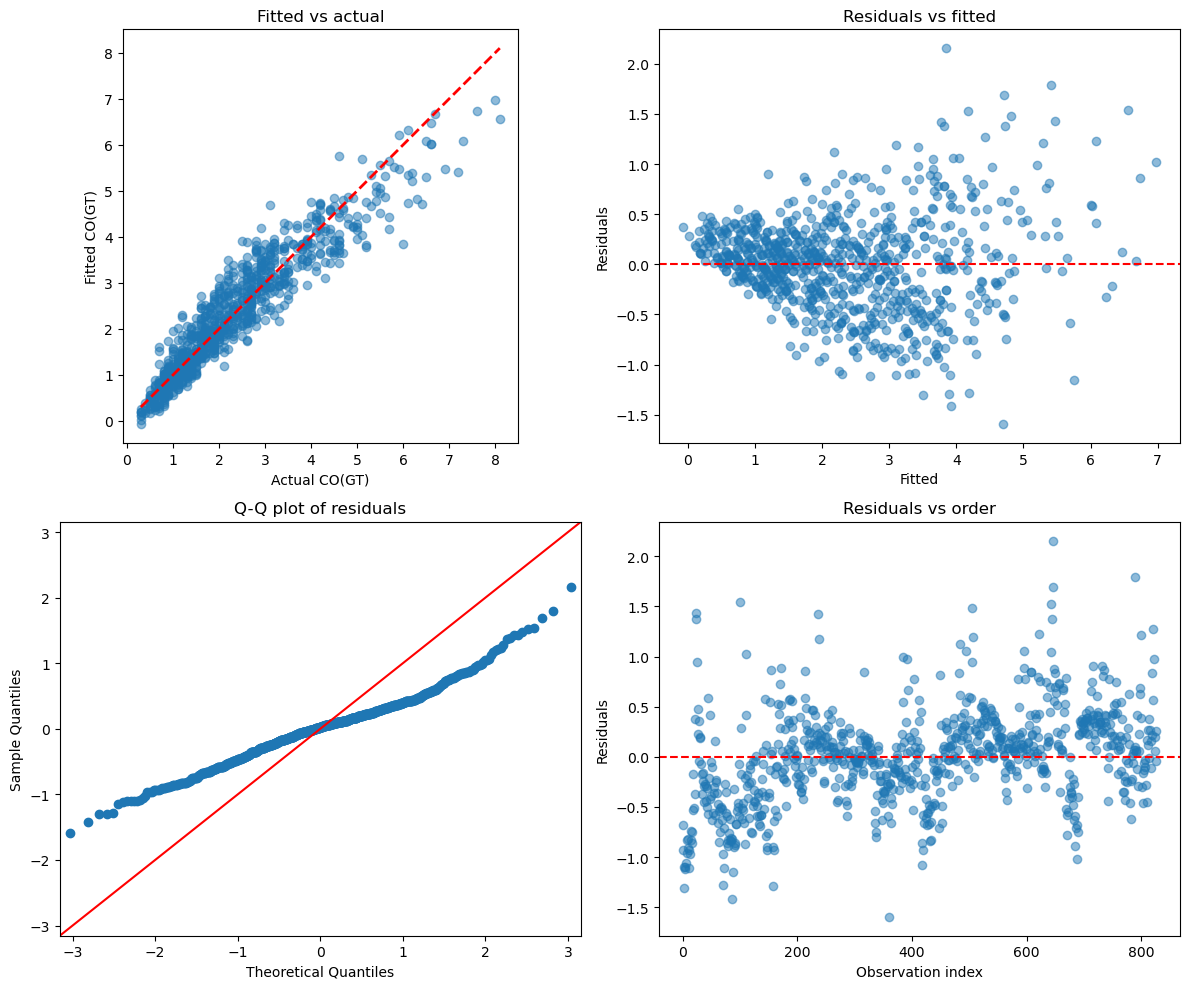

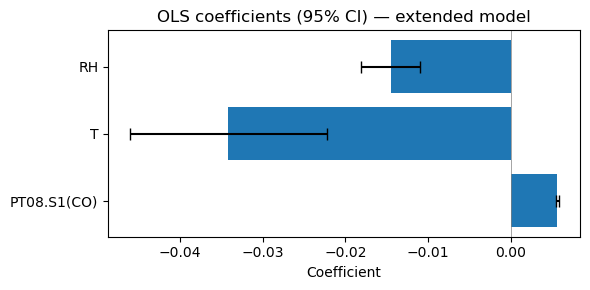

In [56]:
# Use main model
x_CO2 = df[['PT08.S1(CO)', 'T', 'RH']]
y_CO2 = df['CO(GT)']

# Add constant
x_CO2 = sm.add_constant(x_CO2)

# Fit OLS model
model_CO2 = sm.OLS(y_CO2, x_CO2).fit()

fitted = model_CO2.fittedvalues
resid = model_CO2.resid

# 1. Fitted vs actual
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(y_CO2, fitted, alpha=0.5)
axes[0,0].plot([y_CO2.min(), y_CO2.max()], [y_CO2.min(), y_CO2.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual CO(GT)')
axes[0,0].set_ylabel('Fitted CO(GT)')
axes[0,0].set_title('Fitted vs actual')
axes[0,0].set_aspect('equal', adjustable='box')

# 2. Residuals vs fitted
axes[0,1].scatter(fitted, resid, alpha=0.5)
axes[0,1].axhline(0, color='r', linestyle='--')
axes[0,1].set_xlabel('Fitted')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residuals vs fitted')

# 3. Q-Q plot of residuals
sm.qqplot(resid, line='45', ax=axes[1,0])
axes[1,0].set_title('Q-Q plot of residuals')

# 4. Residuals vs observation index (time order)
axes[1,1].scatter(range(len(resid)), resid, alpha=0.5)
axes[1,1].axhline(0, color='r', linestyle='--')
axes[1,1].set_xlabel('Observation index')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals vs order')

plt.tight_layout()
plt.show()

# 5. Coefficient plot (main model)
coef = model_CO2.params.drop('const')
ci = model_CO2.conf_int().loc[coef.index]

err_lo = (coef - ci.iloc[:, 0]).values
err_hi = (ci.iloc[:, 1] - coef).values

fig, ax = plt.subplots(figsize=(6, 3))
y_pos = range(len(coef))

ax.barh(y_pos, coef, xerr=np.array([err_lo, err_hi]), capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef.index)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax.set_xlabel('Coefficient')
ax.set_title('OLS coefficients (95% CI) — extended model')

plt.tight_layout()
plt.show()

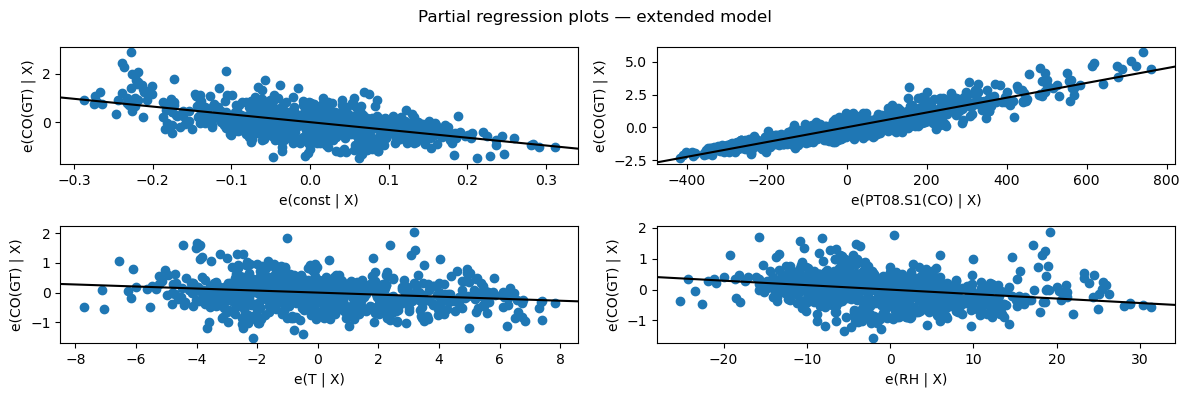

In [57]:
# Partial regression plots (effect of each predictor after controlling for others)
fig = plot_partregress_grid(model_CO2, fig=plt.figure(figsize=(12, 4)))
plt.suptitle('Partial regression plots — extended model')
plt.tight_layout()
plt.show()

In [58]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


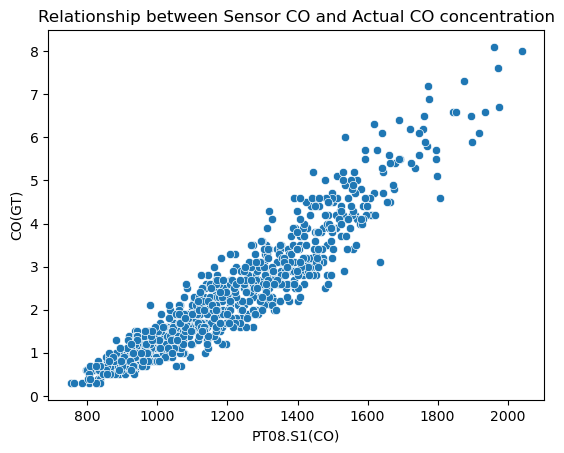

In [59]:
plt.figure()
sns.scatterplot(df, x = "PT08.S1(CO)", y = "CO(GT)")
plt.title("Relationship between Sensor CO and Actual CO concentration")
plt.show()

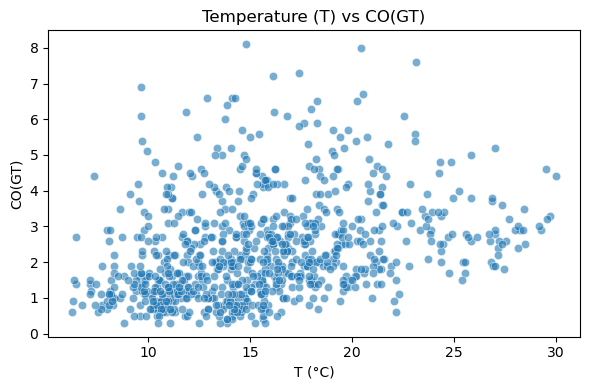

In [60]:
# Temperature vs CO(GT) — supports negative coefficient in regression
plt.figure(figsize=(6, 4))
sns.scatterplot(df, x='T', y='CO(GT)', alpha=0.6)
plt.title('Temperature (T) vs CO(GT)')
plt.xlabel('T (°C)')
plt.ylabel('CO(GT)')
plt.tight_layout()
plt.show()

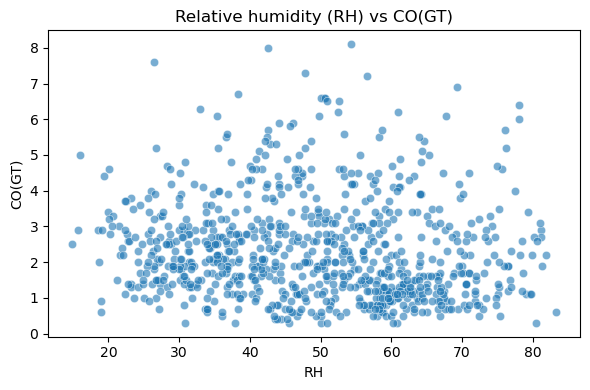

In [61]:
# Relative humidity vs CO(GT) — supports negative coefficient in regression
plt.figure(figsize=(6, 4))
sns.scatterplot(df, x='RH', y='CO(GT)', alpha=0.6)
plt.title('Relative humidity (RH) vs CO(GT)')
plt.xlabel('RH')
plt.ylabel('CO(GT)')
plt.tight_layout()
plt.show()

## Model 4: Extended with Weekday Effects

Incorporating the Time Variable into the Regression Model

In [62]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [63]:
# Extract hour from time column
df['hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

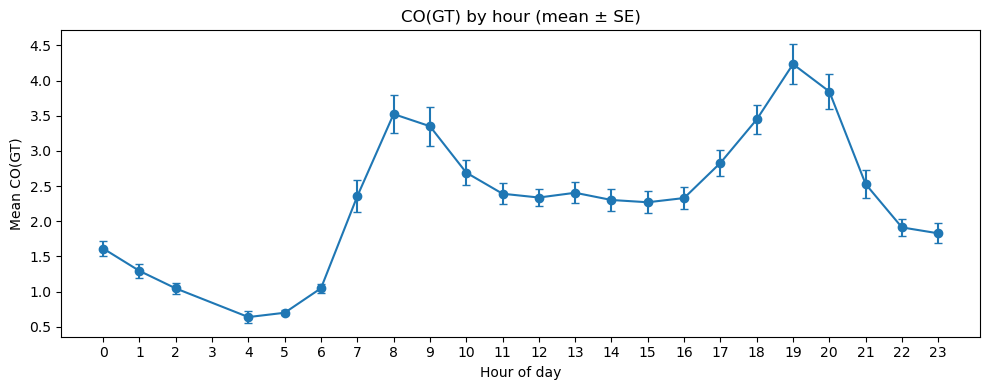

In [64]:
# CO(GT) by hour of day (aligns with regression when including 'hour')
df_h = df.groupby('hour')['CO(GT)'].agg(['mean', 'std', 'count']).reset_index()
df_h['se'] = df_h['std'] / np.sqrt(df_h['count'])
plt.figure(figsize=(10, 4))
plt.errorbar(df_h['hour'], df_h['mean'], yerr=df_h['se'], marker='o', capsize=3)
plt.xlabel('Hour of day')
plt.ylabel('Mean CO(GT)')
plt.title('CO(GT) by hour (mean ± SE)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [65]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,hour
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,18
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,19
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,20
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,21
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,22


In [66]:
# Extract weekday name from date
df['weekday'] = df['Date'].dt.day_name()

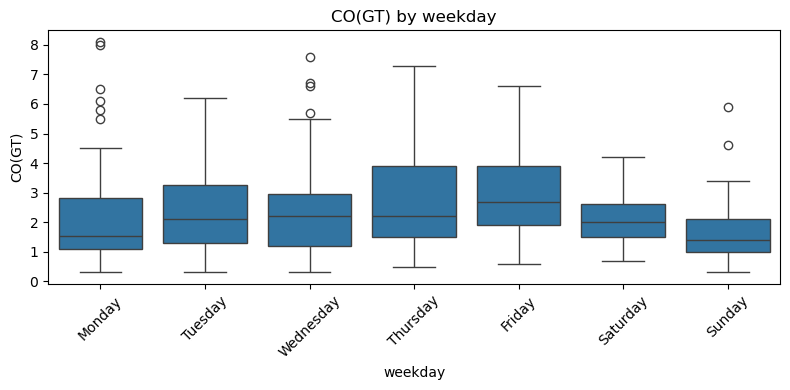

In [67]:
# CO(GT) by weekday (aligns with regression when including weekday dummies)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='weekday', y='CO(GT)', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.xticks(rotation=45)
plt.title('CO(GT) by weekday')
plt.tight_layout()
plt.show()

In [68]:
# Convert weekday into dummy variables (drop reference category)
df = pd.get_dummies(df, columns=['weekday'], drop_first=True)

In [69]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),...,T,RH,AH,hour,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday
0,2004-03-10,18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.0,1056.25,113.0,...,13.60,48.875001,0.757754,18,False,False,False,False,False,True
1,2004-03-10,19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.0,1173.75,92.0,...,13.30,47.700000,0.725487,19,False,False,False,False,False,True
2,2004-03-10,20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.0,1140.00,114.0,...,11.90,53.975000,0.750239,20,False,False,False,False,False,True
3,2004-03-10,21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.0,1092.00,122.0,...,11.00,60.000000,0.786713,21,False,False,False,False,False,True
4,2004-03-10,22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.0,1205.00,116.0,...,11.15,59.575001,0.788794,22,False,False,False,False,False,True


In [70]:
# Define predictors and target
x_hour = df[['PT08.S1(CO)', 'T', 'RH', 'hour']]
y_hour = df['CO(GT)']

# Fit linear regression model
model_hour = LinearRegression()
model_hour.fit(x_hour, y_hour)

# Print intercept and coefficients
print("Intercept:", round(model_hour.intercept_,4))
print("\nCoefficients:")

for var, coef in zip(x_hour.columns, model_hour.coef_):
    print(f"{var}: {coef:.4f}")

Intercept: -3.3049

Coefficients:
PT08.S1(CO): 0.0055
T: -0.0342
RH: -0.0131
hour: 0.0111


In [71]:
x_hour = df[['PT08.S1(CO)', 'T', 'RH', 'hour']]
y_hour = df['CO(GT)']

# Add constant term
x_hour = sm.add_constant(x_hour)

# Fit OLS model
model_hour = sm.OLS(y_hour, x_hour).fit()

# Print regression summary
print(model_hour.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     1630.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:08:36   Log-Likelihood:                -551.41
No. Observations:                 827   AIC:                             1113.
Df Residuals:                     822   BIC:                             1136.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.3049      0.160    -20.700      

## Most Polluted Day Analysis

In [72]:
# Select predictors and target
x_Most_Polluted_day = df[['PT08.S1(CO)','T','RH','weekday_Tuesday',
        'weekday_Wednesday','weekday_Thursday',
        'weekday_Monday','weekday_Saturday','weekday_Sunday']]

y_Most_Polluted_day = df['CO(GT)']

# Fit linear regression
Most_Polluted_day = LinearRegression()
Most_Polluted_day.fit(x_Most_Polluted_day, y_Most_Polluted_day)

# Print intercept and coefficients
print("Intercept:", round(Most_Polluted_day.intercept_,4))
print("\nCoefficients:")

for var, coef in zip(x_Most_Polluted_day.columns, Most_Polluted_day.coef_):
    print(f"{var}: {coef:.4f}")

Intercept: -2.8625

Coefficients:
PT08.S1(CO): 0.0056
T: -0.0366
RH: -0.0161
weekday_Tuesday: -0.1879
weekday_Wednesday: -0.2451
weekday_Thursday: -0.0409
weekday_Monday: -0.1429
weekday_Saturday: -0.3153
weekday_Sunday: -0.2470


In [73]:
# Copy predictors and target
x_Most_Polluted_day = df[['PT08.S1(CO)', 'T', 'RH', 'weekday_Tuesday',
        'weekday_Wednesday', 'weekday_Thursday',
        'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday']].copy()

y_Most_Polluted_day = df['CO(GT)'].copy()

# Convert dummy variables to integers
dummy_cols = ['weekday_Tuesday', 'weekday_Wednesday', 'weekday_Thursday',
              'weekday_Monday', 'weekday_Saturday', 'weekday_Sunday']

# Add constant term
x_Most_Polluted_day[dummy_cols] = x_Most_Polluted_day[dummy_cols].astype(int)

x_Most_Polluted_day = sm.add_constant(x_Most_Polluted_day)

# Fit OLS model
model_Most_Polluted_day = sm.OLS(y_Most_Polluted_day, x_Most_Polluted_day).fit()

# Print summary
print(model_Most_Polluted_day.summary())


                            OLS Regression Results                            
Dep. Variable:                 CO(GT)   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     742.2
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:08:36   Log-Likelihood:                -540.25
No. Observations:                 827   AIC:                             1100.
Df Residuals:                     817   BIC:                             1148.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.8625      0.18

## Out-of-sample forecasting

Train on the first 80% of the data (by time) and evaluate forecasts on the last 20%. Uses the main model CO(GT) = PT08.S1(CO) + T + RH.

In [74]:
# Sort by Date and Time so the split is chronological
df_f = df.sort_values(['Date', 'Time']).reset_index(drop=True)

n = len(df_f)
train_size = int(0.80 * n)

train_df = df_f.iloc[:train_size]
test_df = df_f.iloc[train_size:]

# Predictors and target (main model)
X_train = train_df[['PT08.S1(CO)', 'T', 'RH']]
y_train = train_df['CO(GT)']

X_test = test_df[['PT08.S1(CO)', 'T', 'RH']]
y_test = test_df['CO(GT)']

# Add constant
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit model on train only
model_forecast = sm.OLS(y_train, X_train).fit()

# Predict on test
y_pred = model_forecast.predict(X_test)

# Metrics
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print(f"Train size: {train_size}, Test size: {len(y_test)}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

Train size: 661, Test size: 166
MAE:  0.3874
RMSE: 0.4745
MAPE: 20.75%


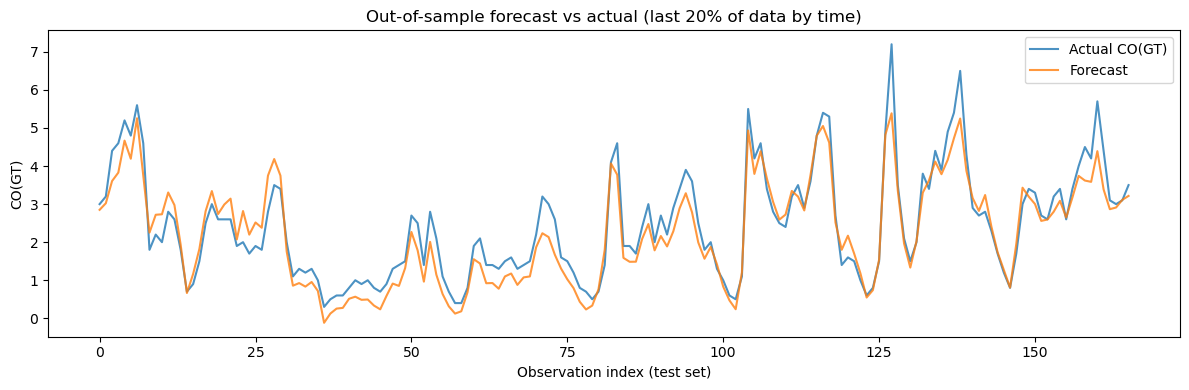

In [75]:
# Plot: actual vs forecast over the test period
plt.figure(figsize=(12, 4))
idx = range(len(y_test))
plt.plot(idx, y_test.values, label='Actual CO(GT)', alpha=0.8)
plt.plot(idx, y_pred, label='Forecast', alpha=0.8)
plt.xlabel('Observation index (test set)')
plt.ylabel('CO(GT)')
plt.title('Out-of-sample forecast vs actual (last 20% of data by time)')
plt.legend()
plt.tight_layout()
plt.show()

## Models Evaluation

This section compares model performance using R², MAE, and RMSE to evaluate which model provides better predictive accuracy

In [76]:
# Function to compute error metrics
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)      # average absolute error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # penalizes larger errors
    return mae, rmse


# Predictions for each model
y_pred_2 = model_CO.predict(x_CO)           # Model 2 (refined)
y_pred_3 = model_hour.predict(x_hour)       # Model 3 (with hour)
y_pred_4 = model_CO2.predict(x_CO2) # Model 4 (with weekday)


# Compute metrics
mae_2, rmse_2 = evaluate_model(y_CO, y_pred_2)
mae_3, rmse_3 = evaluate_model(y_CO, y_pred_3)
mae_4, rmse_4 = evaluate_model(y_CO, y_pred_4)


# Create comparison table
results = pd.DataFrame({
    "Model": ["Model 2", "Model 3", "Model 4"],
    "R²": [
        model_CO.rsquared,
        model_hour.rsquared,
        model_CO2.rsquared
    ],
    "MAE": [mae_2, mae_3, mae_4],
    "RMSE": [rmse_2, rmse_3, rmse_4]
})


# Print results
print(results)

     Model        R²       MAE      RMSE
0  Model 2  0.885888  0.358304  0.475846
1  Model 3  0.888040  0.354125  0.471339
2  Model 4  0.885604  0.358343  0.476439


## Cross Validation

In [79]:
# Variables
X = df_f[['PT08.S1(CO)', 'T', 'RH']]
y = df_f['CO(GT)']

# Time series split
tscv = TimeSeriesSplit(n_splits=5)

mae_list = []
rmse_list = []

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Add constant
    X_train = sm.add_constant(X_train)
    X_test = sm.add_constant(X_test)

    # Train model
    model = sm.OLS(y_train, X_train).fit()

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mae_list.append(mae)
    rmse_list.append(rmse)

# Results
results_cv = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(mae_list))],
    "MAE": [round(x, 4) for x in mae_list],
    "RMSE": [round(x, 4) for x in rmse_list]
})

print(results_cv)

print("\nAverage MAE:", round(np.mean(mae_list), 4))
print("Average RMSE:", round(np.mean(rmse_list), 4))

     Fold     MAE    RMSE
0  Fold 1  0.5977  0.6796
1  Fold 2  0.2766  0.3894
2  Fold 3  0.4022  0.4853
3  Fold 4  0.4219  0.6066
4  Fold 5  0.3808  0.4735

Average MAE: 0.4159
Average RMSE: 0.5269


In [ ]:
# The model shows moderate predictive performance with an average MAE of 0.416. However, 
# variability across folds suggests that performance is not consistent over time, indicating limited robustness. 
# While suitable as a baseline model, further improvements are needed for reliable forecasting.